# Neuron subset recluster

* Consider DE testing of the dual innervating cells vs all cells
* What percentile total_counts are the dual innervating cells?


In [1]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import session_info
import sys

In [2]:
plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 300

In [3]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_03/01_broad-labels"
output_dir = base_dir / "data/h5ad/export_03/02_neuron-labels"

#output_dir.mkdir(parents=True, exist_ok=True)

## Read data

In [4]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_neurons.h5ad'))
adata

AnnData object with n_obs × n_vars = 37176 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

In [5]:
adata.var

,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
1500009L16Rik,ENSMUSG00000087651,8,False,False,True,False,False,False,False,False,27.775189,1.959862,14.867525
6330403K07Rik,ENSMUSG00000018451,8,False,False,False,False,False,False,False,True,68.244944,5.809031,37.026987
Abcb1a,ENSMUSG00000040584,8,False,False,False,False,False,False,True,False,0.960015,15.004704,7.982359
Ache,ENSMUSG00000023328,8,False,False,False,False,False,False,True,False,18.361450,0.901537,9.631493
Acta2,ENSMUSG00000035783,5,False,False,False,False,False,False,True,False,0.466027,1.583569,1.024798
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vat1l,ENSMUSG00000046844,8,False,False,False,False,False,False,False,True,37.776121,5.091722,21.433921
Vip,ENSMUSG00000019772,8,False,False,False,False,False,False,True,False,0.000000,0.003920,0.001960
Vwf,ENSMUSG00000001930,8,False,False,False,False,False,False,True,False,0.615155,3.696300,2.155727
Wfdc18,ENSMUSG00000000983,6,False,False,False,False,False,True,False,False,0.233013,2.826121,1.529567


## Subset adata.var

In [6]:
cols = ["zhen_list", "neurons_supervised", "neurons_unsupervised", "neuron_DEGs"]

truthy_values = {"true", "t", "yes", "y", "1"}

for c in cols:
    adata.var[c] = (
        adata.var[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(truthy_values)
    )

In [7]:
for c in cols:
    print(f"{c}: {adata.var[c].sum()} True")

zhen_list: 122 True
neurons_supervised: 49 True
neurons_unsupervised: 17 True
neuron_DEGs: 24 True


In [8]:
cols = ["zhen_list", "neurons_supervised", "neurons_unsupervised", "neuron_DEGs"]

mask = adata.var[cols].any(axis=1)

genes_keep = adata.var_names[mask]
print(f"Selected {mask.sum()} genes")

adata_subset = adata[:, mask].copy()
adata_subset

Selected 212 genes


AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

In [9]:
adata_subset.var

,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
1500009L16Rik,ENSMUSG00000087651,8,False,False,True,False,False,False,False,False,27.775189,1.959862,14.867525
6330403K07Rik,ENSMUSG00000018451,8,False,False,False,False,False,False,False,True,68.244944,5.809031,37.026987
Adcyap1,ENSMUSG00000024256,8,True,False,False,False,False,False,False,False,36.862709,0.889777,18.876243
Adgrg2,ENSMUSG00000031298,8,False,False,True,False,False,False,False,False,23.254730,1.117121,12.185926
Adra2a,ENSMUSG00000033717,8,True,False,False,False,False,False,False,False,4.809395,0.646754,2.728075
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unc5c,ENSMUSG00000059921,8,False,False,True,False,False,False,False,False,10.774536,0.537002,5.655769
Upb1,ENSMUSG00000033427,8,False,False,False,True,False,False,False,False,13.757107,0.356695,7.056901
Vamp1,ENSMUSG00000030337,8,False,False,True,False,False,False,False,False,48.960761,8.815459,28.888110
Vat1l,ENSMUSG00000046844,8,False,False,False,False,False,False,False,True,37.776121,5.091722,21.433921


# PCA

In [10]:
adata_subset.X = adata_subset.layers['log1p'].copy()

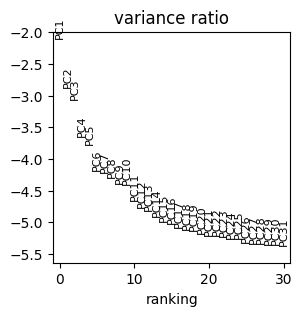

In [11]:
# Step 1: Normalize and scale
sc.pp.scale(adata_subset, max_value=10)

# Step 2: Run PCA
sc.tl.pca(adata_subset, svd_solver='arpack')

# Optional: Visualize explained variance
sc.pl.pca_variance_ratio(adata_subset, log=True)

In [12]:
sc.pp.neighbors(adata_subset, n_pcs=20)
sc.tl.umap(adata_subset)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
sc.tl.leiden(adata_subset, key_added="neuron_recluster", resolution=0.4)

/tmp/ipykernel_4391/3517374300.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_subset, key_added="neuron_recluster", resolution=0.4)


In [14]:
adata_subset

AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean', 'mean', '

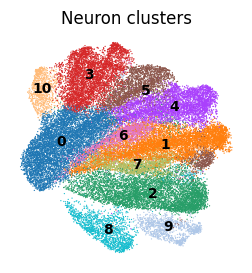

In [15]:
sc.pl.umap(adata_subset, color = 'neuron_recluster', frameon = False, legend_loc = 'on data', title = 'Neuron clusters')

Found in adata_subset: ['bpoikicj-1-1', 'akcoadof-1-2', 'bgmdeeeb-1-2', 'hjjgalia-1-2', 'bmjgagok-1-3', 'ijnggkoc-1-3']


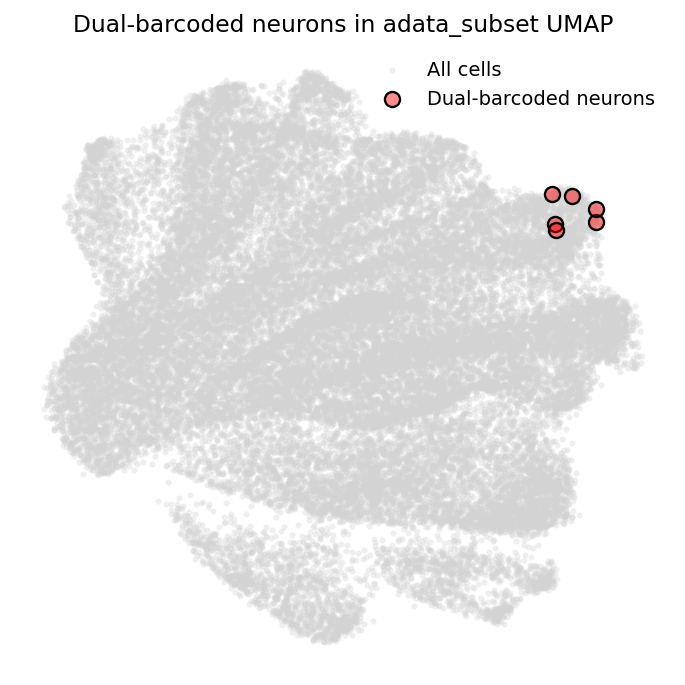

In [16]:
# List of barcoded neurons
dual_barcodes = [
    'bpoikicj-1-1',
    'akcoadof-1-2',
    'bgmdeeeb-1-2',
    'hjjgalia-1-2',
    'bmjgagok-1-3',
    'ijnggkoc-1-3'
]

# Make sure these exist in adata_subset
dual_mask = adata_subset.obs_names.isin(dual_barcodes)

print("Found in adata_subset:", adata_subset.obs_names[dual_mask].tolist())

# Convert barcodes to integer indices
dual_indices = [adata_subset.obs_names.get_loc(cell) for cell in adata_subset.obs_names[dual_mask]]

# UMAP coordinates
umap = adata_subset.obsm["X_umap"]

# Visualization
plt.figure(figsize=(5,5), dpi=140)

# Background cells
plt.scatter(
    umap[:, 0],
    umap[:, 1],
    c="lightgray",
    s=5, alpha=0.25,
    label="All cells"
)

# Highlight dual-barcoded neurons
plt.scatter(
    umap[dual_indices, 0],
    umap[dual_indices, 1],
    s=60,
    facecolors=(1, 0, 0, 0.45),  # translucent red fill
    edgecolors="black",
    linewidths=1.2,
    marker="o",
    label="Dual-barcoded neurons"
)

plt.title("Dual-barcoded neurons in adata_subset UMAP")
plt.xticks([]); plt.yticks([])
plt.legend(frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in

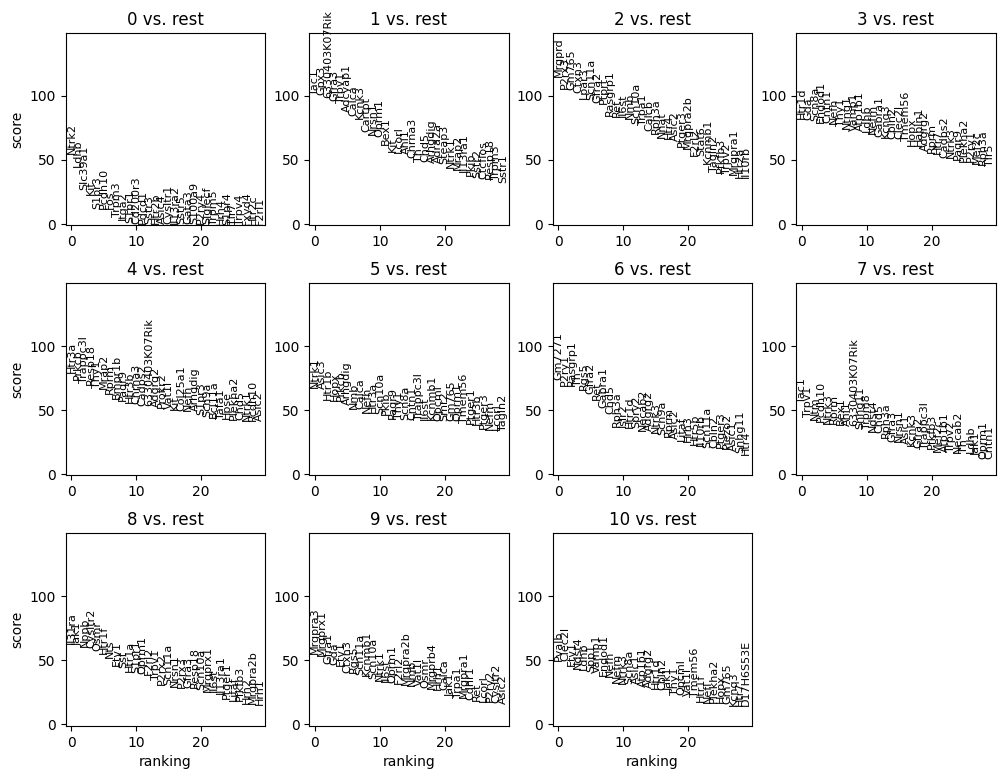

In [17]:
sc.tl.rank_genes_groups(adata_subset, groupby="neuron_recluster", method="wilcoxon", use_raw = False)
sc.pl.rank_genes_groups(adata_subset, groupby="neuron_recluster", n_genes=30, size=8, use_raw = False)

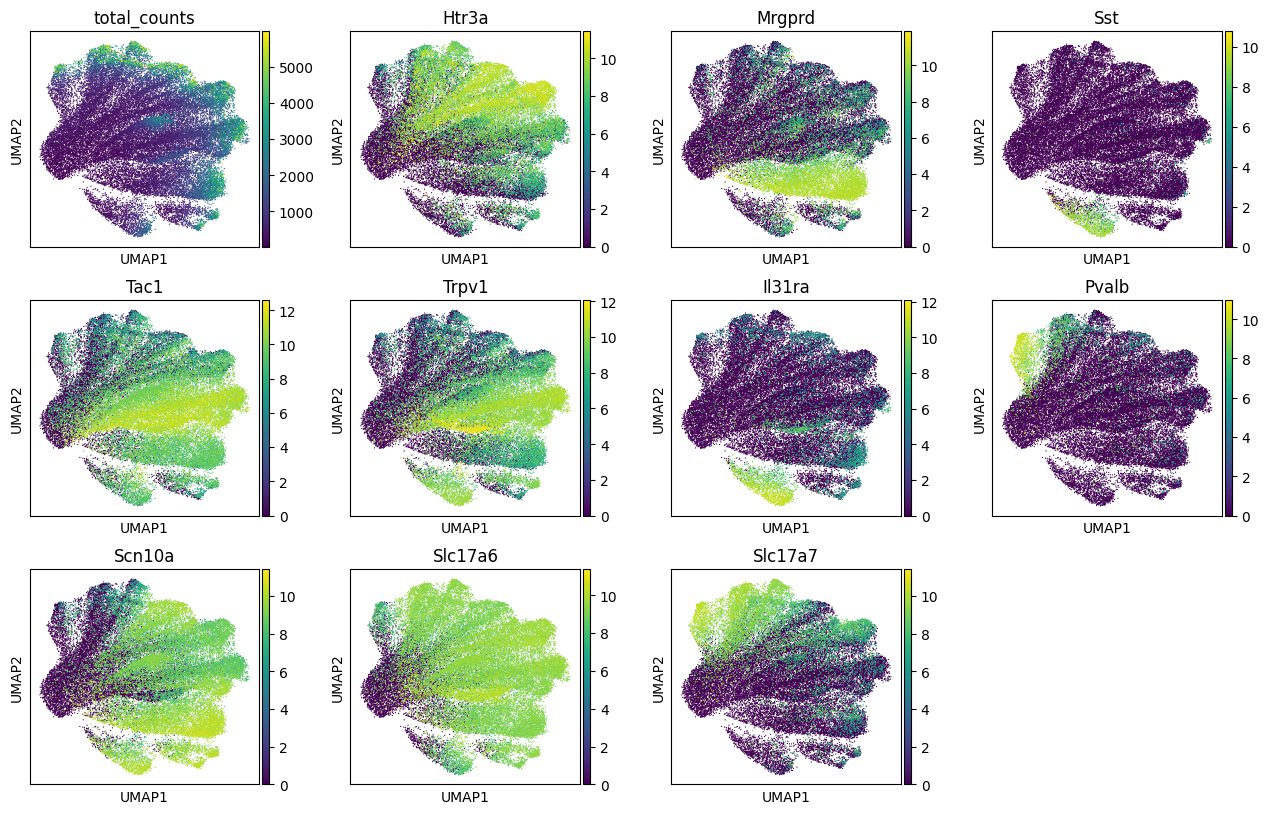

In [18]:
sc.pl.umap(adata_subset, color = ['total_counts', 'Htr3a', 'Mrgprd', 'Sst', 'Tac1', 'Trpv1', 'Il31ra', 'Pvalb', 'Scn10a', 'Slc17a6', 'Slc17a7'])

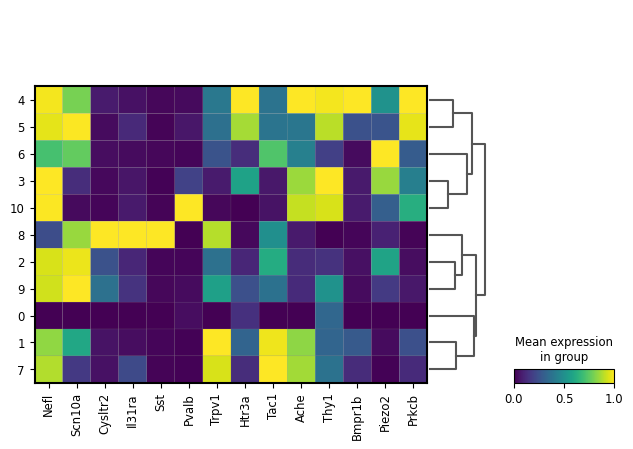

In [19]:
genes = ['Nefl', 'Scn10a', 'Cysltr2', 'Il31ra', 'Sst', 'Pvalb', 'Trpv1', 'Htr3a', 'Tac1', 'Ache', 'Thy1', 'Bmpr1b', 'Piezo2', 'Prkcb']
sc.tl.dendrogram(adata_subset, groupby = 'neuron_recluster')
sc.pl.matrixplot(adata_subset, var_names = genes, groupby = 'neuron_recluster', standard_scale = 'var', dendrogram = True)

## export

In [20]:
filename = os.path.join(output_dir, 'neuron-pca.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata_subset.write_h5ad(filename, compression='gzip')

## Session info

In [21]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
